# Ten biogeographic regions and classification units


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import os
import palettable
import geopandas as gpd
import cartopy.crs as ccrs
import ZhenPlot

from matplotlib.patches import Patch
import matplotlib.colors as mcolors

plt.rcParams['font.sans-serif'] = ['Arial']
%config InlineBackend.figure_format = 'retina'

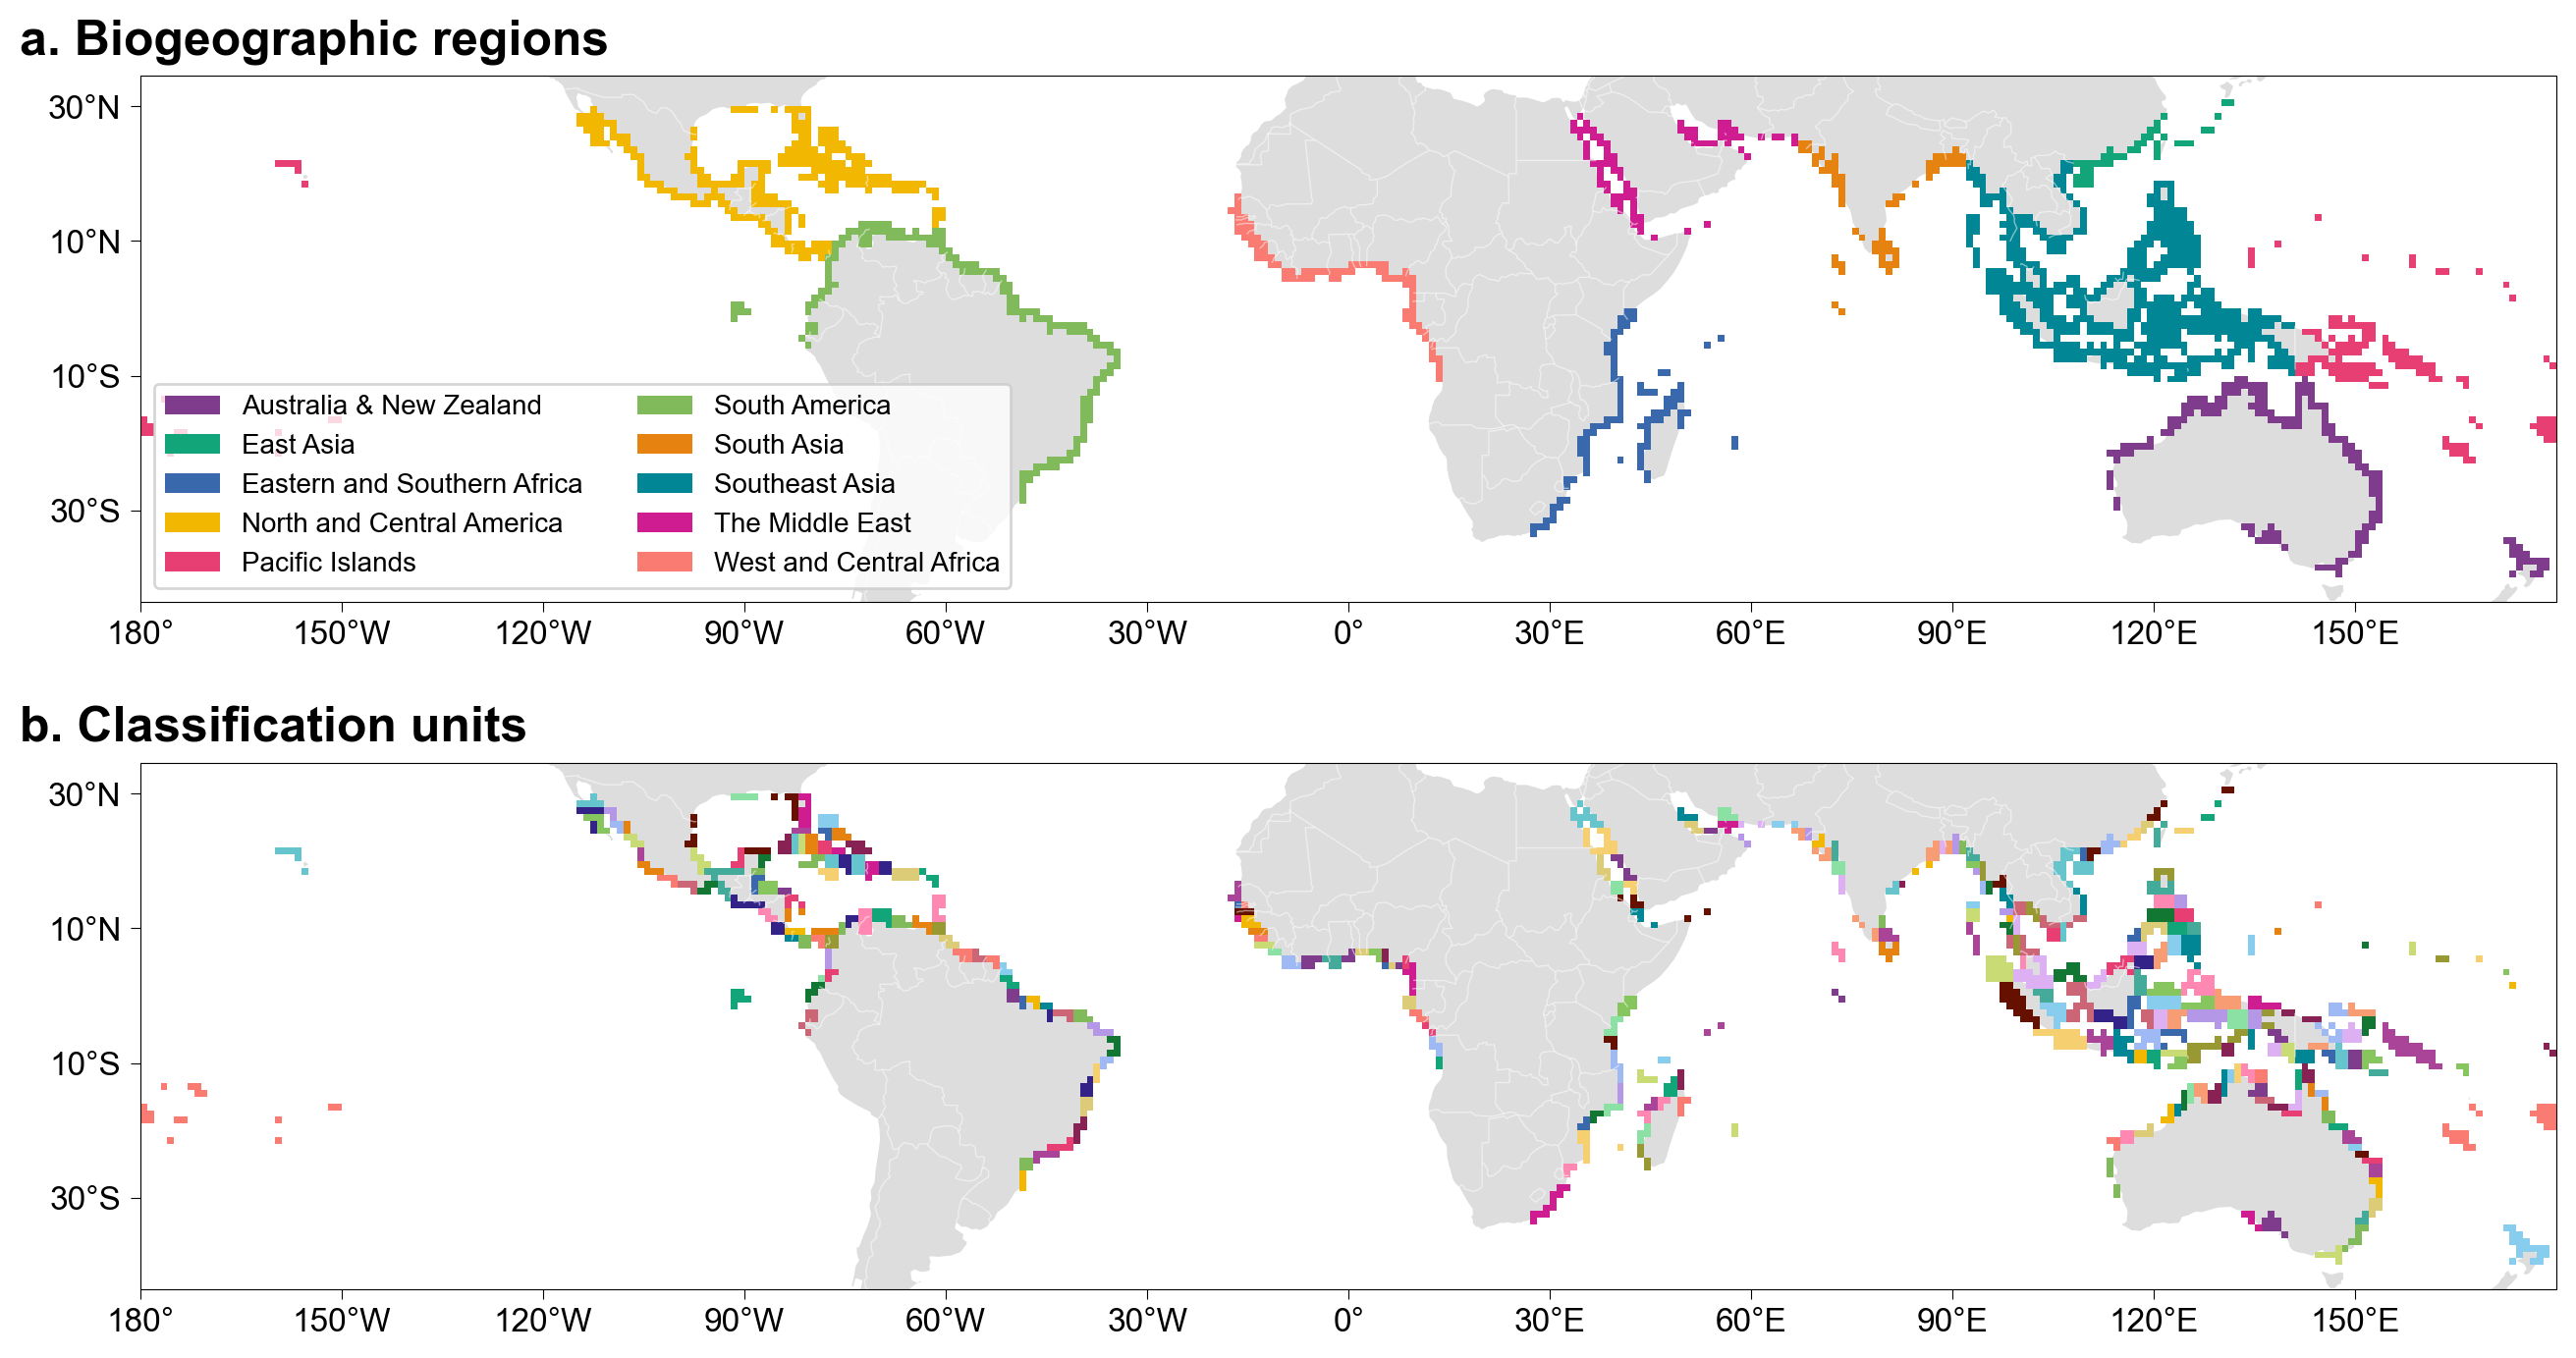

: 

In [ ]:
grids = gpd.read_file(r'D:\Data\GMD\ForPloting\Grid_1degree_ForPloting.shp')
grids['Continent'] = grids['Continent'].replace(['Australia','NewZealand'], 'Australia & New Zealand')
grids['Continent'] = grids['Continent'].replace(['Fiji','SEA2','Hawaii'], 'Pacific Islands')
grids['Continent'] = grids['Continent'].replace({'EasternAfrica': 'Eastern and Southern Africa',
                                                 "WesternAfrica": "West and Central Africa",
                                                 "NorthAmerica": "North and Central America",
                                                 "SouthAmerica": "South America",
                                                 "MiddleEast": "The Middle East",
                                                 "SEA1": "Southeast Asia",
                                                 "SouthAsia": "South Asia"})

grids.Continent.unique()
fig = plt.figure(figsize=(13, 7),constrained_layout=True)
gs = GridSpec(nrows=2, ncols=1,figure=fig)

ax = fig.add_subplot(gs[0,0],projection=ccrs.PlateCarree())
labels = np.sort(grids.Continent.unique())
colors = palettable.cartocolors.qualitative.Bold_10.hex_colors
cmap = mcolors.ListedColormap(palettable.cartocolors.qualitative.Bold_10.hex_colors)
ZhenPlot.add_basemap(ax,xticks=True,yticks=True,fontsize=12,xrange=np.arange(-180,180,30))
grids.plot(column='Continent',ax=ax,cmap=cmap,categorical=True,legend=False) 
ax.text(-0.05,1.04,'a. Biogeographic regions',fontdict={'weight' : 'bold', 'size' : 18},transform=ax.transAxes)
legend_elements = [Patch(facecolor=colors[i], label=str(labels[i])) for i in range(labels.size)]
ax.legend(handles=legend_elements,ncol=2, loc='lower left', frameon=True, fontsize=10)
ZhenPlot.spine_setting(ax,linewidth=0.4)

ax = fig.add_subplot(gs[1,0],projection=ccrs.PlateCarree())
colors = palettable.cartocolors.qualitative.Bold_10.hex_colors+palettable.cartocolors.qualitative.Pastel_10.hex_colors+palettable.cartocolors.qualitative.Safe_10.hex_colors
cmap = mcolors.ListedColormap(colors)
ZhenPlot.add_basemap(ax,xticks=True,yticks=True,fontsize=12,xrange=np.arange(-180,180,30))
grids.plot(column='RegionName',ax=ax,cmap=cmap,categorical=True,legend=False) 
ax.text(-0.05,1.04,'b. Classification units',fontdict={'weight' : 'bold', 'size' : 18},transform=ax.transAxes)
ZhenPlot.spine_setting(ax,linewidth=0.4)

plt.savefig(r"D:\OneDriveFolder\OneDrive\Manuscript\GlobalMangroveDynamics\Figures\StudyArea.png", dpi=500, format='png', bbox_inches='tight')
plt.savefig(r"D:\OneDriveFolder\OneDrive\Manuscript\GlobalMangroveDynamics\Figures\StudyArea.svg", dpi=500, format='svg', bbox_inches='tight')